<a href="https://colab.research.google.com/github/gopal50g/ml-lumbinidata/blob/main/lumbinisolar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from google.colab import files
import io

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#loading data
df = pd.read_csv('/content/drive/MyDrive/lumbini_solar.csv', sep=None, engine='python', skiprows=2)


In [ ]:
df.head(31)

,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,...,3.9550 um,3.9600 um,3.9650 um,3.9700 um,3.9750 um,3.9800 um,3.9850 um,3.9900 um,3.9950 um,4.0000 um
0,2020,1,1,0,0,10.7,0.0,0.0,0.0,7.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
1,2020,1,1,1,0,10.1,0.0,0.0,0.0,6.0,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
2,2020,1,1,2,0,11.5,40.0,170.0,58.0,6.0,...,3.763923e-03,3.828077e-03,3.886636e-03,3.690793e-03,3.386512e-03,3.255601e-03,3.307373e-03,3.153963e-03,2.954478e-03,2.802350e-03
3,2020,1,1,3,0,15.2,107.0,437.0,234.0,6.0,...,2.119754e-03,2.103337e-03,2.087800e-03,1.999507e-03,1.886361e-03,1.813341e-03,1.789601e-03,1.716130e-03,1.628367e-03,1.554559e-03
4,2020,1,1,4,0,17.1,149.0,576.0,406.0,7.0,...,2.221395e+00,2.244997e+00,2.270259e+00,2.224973e+00,2.148680e+00,2.105960e+00,2.120740e+00,2.084134e+00,2.025950e+00,1.979215e+00
5,2020,1,1,5,0,18.1,180.0,626.0,529.0,7.0,...,1.192328e+00,1.199606e+00,1.208564e+00,1.184312e+00,1.150015e+00,1.130812e+00,1.133484e+00,1.114866e+00,1.086949e+00,1.065286e+00
6,2020,1,1,6,0,18.4,192.0,661.0,600.0,7.0,...,2.180515e+00,2.192911e+00,2.208958e+00,2.167818e+00,2.112096e+00,2.081398e+00,2.085859e+00,2.054508e+00,2.007990e+00,1.972819e+00
7,2020,1,1,7,0,18.9,201.0,648.0,606.0,6.0,...,9.325702e-01,9.361014e-01,9.412663e-01,9.217823e-01,8.968624e-01,8.827612e-01,8.828665e-01,8.681872e-01,8.470872e-01,8.309635e-01
8,2020,1,1,8,0,19.4,191.0,623.0,549.0,7.0,...,3.253987e+00,3.277398e+00,3.305908e+00,3.244237e+00,3.158326e+00,3.112608e+00,3.123580e+00,3.077629e+00,3.006593e+00,2.952907e+00
9,2020,1,1,9,0,19.3,166.0,558.0,432.0,6.0,...,2.040278e-03,2.010594e-03,1.983989e-03,1.900550e-03,1.809859e-03,1.746585e-03,1.710859e-03,1.643581e-03,1.565932e-03,1.500726e-03


In [ ]:

df.shape

(8784, 2034)

In [ ]:
df.columns[:]

Index(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Temperature', 'Clearsky DHI',
       'Clearsky DNI', 'Clearsky GHI', 'Cloud Type',
       ...
       '3.9550 um', '3.9600 um', '3.9650 um', '3.9700 um', '3.9750 um',
       '3.9800 um', '3.9850 um', '3.9900 um', '3.9950 um', '4.0000 um'],
      dtype='object', length=2034)

In [ ]:
df.columns[:32],df.columns[32:60],df.columns[60:]

(Index(['Year', 'Month', 'Day', 'Hour', 'Minute', 'Temperature', 'Clearsky DHI',
        'Clearsky DNI', 'Clearsky GHI', 'Cloud Type', 'Dew Point', 'DHI', 'DNI',
        'Fill Flag', 'GHI', 'Relative Humidity', 'Solar Zenith Angle',
        'Surface Albedo', 'Pressure', 'Precipitable Water', 'Wind Direction',
        'Wind Speed', 'Si (BPR)', 'Si (Wacker)', 'Si (Eurosil)',
        'GaAs (Bauhuis et al., 2009)', 'InGap (Gray, 2008)',
        'InGap (McGambridge, 2011)', 'CdTe', 'Solar Azimuth Angle',
        'Panel Tilt', 'Panel Azimuth Angle'],
       dtype='object'),
 Index(['0.2800 um', '0.2805 um', '0.2810 um', '0.2815 um', '0.2820 um',
        '0.2825 um', '0.2830 um', '0.2835 um', '0.2840 um', '0.2845 um',
        '0.2850 um', '0.2855 um', '0.2860 um', '0.2865 um', '0.2870 um',
        '0.2875 um', '0.2880 um', '0.2885 um', '0.2890 um', '0.2895 um',
        '0.2900 um', '0.2905 um', '0.2910 um', '0.2915 um', '0.2920 um',
        '0.2925 um', '0.2930 um', '0.2935 um'],
       dtype

In [ ]:
df['datetime'] = pd.to_datetime(df[['Year','Month','Day','Hour','Minute']])
df = df.set_index('datetime')
df.head(10)

,Year,Month,Day,Hour,Minute,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,...,3.9550 um,3.9600 um,3.9650 um,3.9700 um,3.9750 um,3.9800 um,3.9850 um,3.9900 um,3.9950 um,4.0000 um
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,2020,1,1,0,0,10.7,0.0,0.0,0.0,7.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-01-01 01:00:00,2020,1,1,1,0,10.1,0.0,0.0,0.0,6.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-01-01 02:00:00,2020,1,1,2,0,11.5,40.0,170.0,58.0,6.0,...,0.003764,0.003828,0.003887,0.003691,0.003387,0.003256,0.003307,0.003154,0.002954,0.002802
2020-01-01 03:00:00,2020,1,1,3,0,15.2,107.0,437.0,234.0,6.0,...,0.002120,0.002103,0.002088,0.002000,0.001886,0.001813,0.001790,0.001716,0.001628,0.001555
2020-01-01 04:00:00,2020,1,1,4,0,17.1,149.0,576.0,406.0,7.0,...,2.221395,2.244997,2.270259,2.224973,2.148680,2.105960,2.120740,2.084134,2.025950,1.979215
2020-01-01 05:00:00,2020,1,1,5,0,18.1,180.0,626.0,529.0,7.0,...,1.192328,1.199606,1.208564,1.184312,1.150015,1.130812,1.133484,1.114866,1.086949,1.065286
2020-01-01 06:00:00,2020,1,1,6,0,18.4,192.0,661.0,600.0,7.0,...,2.180515,2.192911,2.208958,2.167818,2.112096,2.081398,2.085859,2.054508,2.007990,1.972819
2020-01-01 07:00:00,2020,1,1,7,0,18.9,201.0,648.0,606.0,6.0,...,0.932570,0.936101,0.941266,0.921782,0.896862,0.882761,0.882867,0.868187,0.847087,0.830964
2020-01-01 08:00:00,2020,1,1,8,0,19.4,191.0,623.0,549.0,7.0,...,3.253987,3.277398,3.305908,3.244237,3.158326,3.112608,3.123580,3.077629,3.006593,2.952907


In [ ]:
df = df.drop(['Year','Month','Day','Hour','Minute'], axis=1)
df.head()

,Temperature,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Dew Point,DHI,DNI,Fill Flag,GHI,...,3.9550 um,3.9600 um,3.9650 um,3.9700 um,3.9750 um,3.9800 um,3.9850 um,3.9900 um,3.9950 um,4.0000 um
datetime,,,,,,,,,,,,,,,,,,,,,
2020-01-01 00:00:00,10.7,0.0,0.0,0.0,7.0,0.3,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-01-01 01:00:00,10.1,0.0,0.0,0.0,6.0,0.4,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2020-01-01 02:00:00,11.5,40.0,170.0,58.0,6.0,3.3,35.0,0.0,3.0,35.0,...,0.003764,0.003828,0.003887,0.003691,0.003387,0.003256,0.003307,0.003154,0.002954,0.002802
2020-01-01 03:00:00,15.2,107.0,437.0,234.0,6.0,4.9,96.0,0.0,0.0,96.0,...,0.002120,0.002103,0.002088,0.002000,0.001886,0.001813,0.001790,0.001716,0.001628,0.001555
2020-01-01 04:00:00,17.1,149.0,576.0,406.0,7.0,4.5,133.0,552.0,0.0,379.0,...,2.221395,2.244997,2.270259,2.224973,2.148680,2.105960,2.120740,2.084134,2.025950,1.979215


In [ ]:
# cyclic incoding

df['hour_sin'] = np.sin(2*np.pi*df.index.hour/24)
df['hour_cos'] = np.cos(2*np.pi*df.index.hour/24)

df['doy_sin']  = np.sin(2*np.pi*df.index.dayofyear/366)  # 2020 is leap year
df['doy_cos']  = np.cos(2*np.pi*df.index.dayofyear/366)

In [ ]:
df.isna().sum()
#df.fillna(np.median, inplace=True)
df.fillna(df.median(numeric_only=True), inplace=True)

In [ ]:
df.isna().sum()

,0
Year,0
Month,0
Day,0
Hour,0
Minute,0
...,...
3.9800 um,0
3.9850 um,0
3.9900 um,0
3.9950 um,0


In [ ]:
df_copy = df.copy()

In [ ]:
df_new = df_copy[df_copy['Solar Zenith Angle'] != -9999]
df_new = df_new[df_new['Solar Zenith Angle'] <= 90]
df_new = df_new[df_new['GHI'] > 0]

In [ ]:
print(f"Clean rows: {len(df_new)}")
print(f"Zenith range: {df_new['Solar Zenith Angle'].min():.1f} to {df_new['Solar Zenith Angle'].max():.1f}")
print(f"GHI range: {df_new['GHI'].min():.1f} to {df_new['GHI'].max():.1f}")

Clean rows: 4187
Zenith range: 7.1 to 86.0
GHI range: 4.0 to 1020.0


In [ ]:
spectral_cols = [c for c in df_new.columns if c.endswith(' um')]
na_per_column = df_new[spectral_cols].isna().sum()
print("NaN per spectral column:")
print(na_per_column[na_per_column > 0])

total_na_rows = df_new[spectral_cols].isna().any(axis=1).sum()
print(f"\nRows with any NaN in spectra: {total_na_rows}")

NaN per spectral column:
Series([], dtype: int64)

Rows with any NaN in spectra: 0


In [ ]:
df_clean = df_new.dropna(subset=spectral_cols).copy()
#df_clean = df_clean.reset_index(drop=True)

print(f"Before: {len(df_new)} rows")
print(f"After:  {len(df_clean)} rows")

Before: 4187 rows
After:  4187 rows


In [ ]:
df_clean[spectral_cols].sum(axis=1).describe()

,0
count,4.187000e+03
mean,5.675589e+05
std,3.055694e+05
min,3.993457e+03
25%,3.018864e+05
50%,6.468632e+05
75%,8.080786e+05
max,1.048093e+06


In [ ]:
features = ['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos',
            'Temperature', 'Relative Humidity', 'Pressure', 'Precipitable Water',
            'Cloud Type', 'Solar Zenith Angle', 'Solar Azimuth Angle'


          ]
x = df_clean[features]
target = ['Si (BPR)', 'GaAs (Bauhuis et al., 2009)','InGap (Gray, 2008)',
          'CdTe']
y = df_clean[target]


In [ ]:
x.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4187 entries, 2020-01-01 02:00:00 to 2020-12-31 11:00:00
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   hour_sin             4187 non-null   float64
 1   hour_cos             4187 non-null   float64
 2   doy_sin              4187 non-null   float64
 3   doy_cos              4187 non-null   float64
 4   Temperature          4187 non-null   float64
 5   Relative Humidity    4187 non-null   float64
 6   Pressure             4187 non-null   float64
 7   Precipitable Water   4187 non-null   float64
 8   Cloud Type           4187 non-null   float64
 9   Solar Zenith Angle   4187 non-null   float64
 10  Solar Azimuth Angle  4187 non-null   float64
dtypes: float64(11)
memory usage: 392.5 KB


In [ ]:
#y_scaled
y.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4187 entries, 2020-01-01 02:00:00 to 2020-12-31 11:00:00
Data columns (total 4 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Si (BPR)                     4187 non-null   float64
 1   GaAs (Bauhuis et al., 2009)  4187 non-null   float64
 2   InGap (Gray, 2008)           4187 non-null   float64
 3   CdTe                         4187 non-null   float64
dtypes: float64(4)
memory usage: 163.6 KB


In [ ]:
split = int(len(df_clean)*0.8)

X_train1, X_test1 = x[:split], x[split:]
y_train1, y_test1 = y[:split], y[split:]


In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model.fit(X_train1, y_train1)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred = model.predict(X_test1)


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

print("MAE:", mean_absolute_error(y_test1, pred))
print("R2 :", r2_score(y_test1, pred))
print("MSE:", mean_absolute_error(y_test1, pred)**2)

MAE: 0.03222900629043579
R2 : 0.2907284200191498
MSE: 0.0010387088464689498


In [ ]:
for i, t in enumerate(target):
    print(t)
    print("RMSE:", np.sqrt(mean_squared_error(y_test1.iloc[:, i], pred[:, i])))

Si (BPR)
RMSE: 0.042632276954864066
GaAs (Bauhuis et al., 2009)
RMSE: 0.0796388632922319
InGap (Gray, 2008)
RMSE: 0.10843606538615254
CdTe
RMSE: 0.07543123093716125


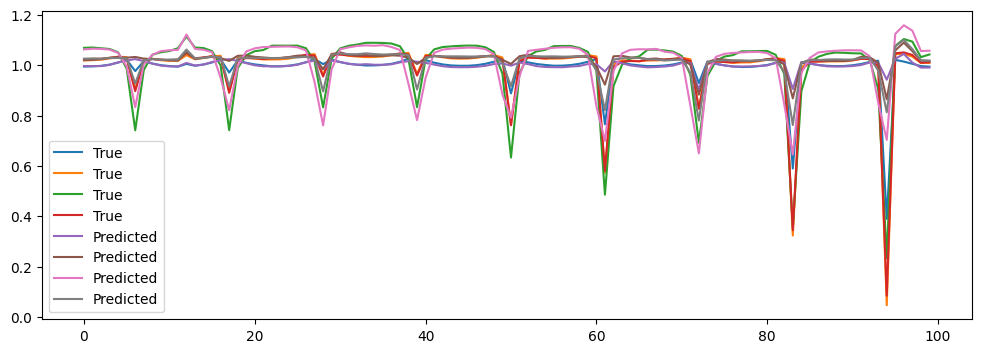

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(y_test1.values[:100], label='True')
plt.plot(pred[:100], label='Predicted')
plt.legend()
plt.show()


In [ ]:
# Model B ( including spectra)


In [ ]:
# Standardize spectra
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
spectral_colsc = [c for c in df_clean.columns if c.endswith(' um')]
X_spec_scaled = scaler.fit_transform(df_clean[spectral_colsc])

In [ ]:
# PCA apply
from sklearn.decomposition import PCA

pca = PCA(n_components=20)

X_pca = pca.fit_transform(X_spec_scaled)

pca_cols = [f'PC{i+1}' for i in range(20)]
df_pca = pd.DataFrame(X_pca,
                      columns=pca_cols,
                      index=df_clean.index)

0.9989181717855936


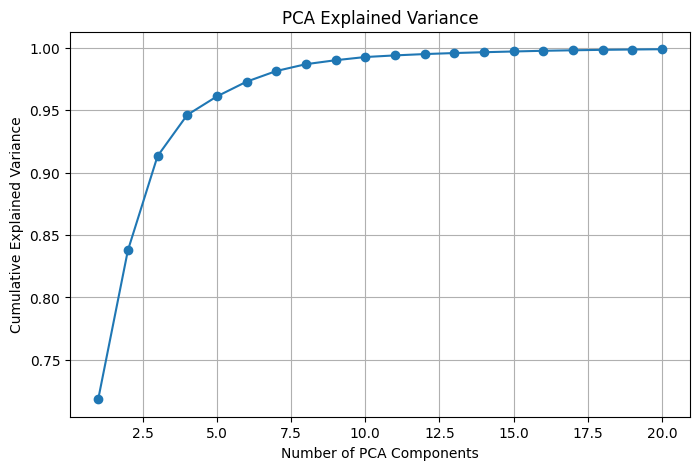

In [ ]:
# Explained Variance

explained = pca.explained_variance_ratio_
cum_explained = explained.cumsum()

print(pca.explained_variance_ratio_.sum())
# Plot Cumulative Variance
plt.figure(figsize=(8,5))

plt.plot(
    np.arange(1, len(cum_explained)+1),
    cum_explained,
    marker='o'
)

plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Explained Variance')

plt.grid(True)

plt.show()

In [ ]:
X_enhanced = pd.concat([x, df_pca],axis=1
              )

In [ ]:
split = int(len(df_clean)*0.8)

X_train2, X_test2 = X_enhanced[:split], X_enhanced[split:]
y_train1, y_test1 = y[:split], y[split:]


In [ ]:
print(x.shape)
print(df_pca.shape)
print(y.shape)

(4187, 11)
(4187, 20)
(4187, 4)


In [ ]:
print(x.index.equals(df_pca.index))
print(x.index.equals(y.index))

True
True


In [ ]:
model2 = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

model2.fit(X_train2, y_train1)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
pred2 = model2.predict(X_test2)


In [ ]:
print("MAE:", mean_absolute_error(y_test1, pred2))
print("R2 :", r2_score(y_test1, pred2))
print("MSE:", mean_squared_error(y_test1, pred2))

MAE: 0.009750964120030403
R2 : 0.8717352151870728
MSE: 0.0011591059155762196


In [ ]:
for i, t in enumerate(target):
    print(t)
    print("RMSE:", np.sqrt(mean_squared_error(y_test1.iloc[:, i], pred2[:, i])))

Si (BPR)
RMSE: 0.02010395777385085
GaAs (Bauhuis et al., 2009)
RMSE: 0.03333840792242745
InGap (Gray, 2008)
RMSE: 0.049590629801980236
CdTe
RMSE: 0.02572111458196183


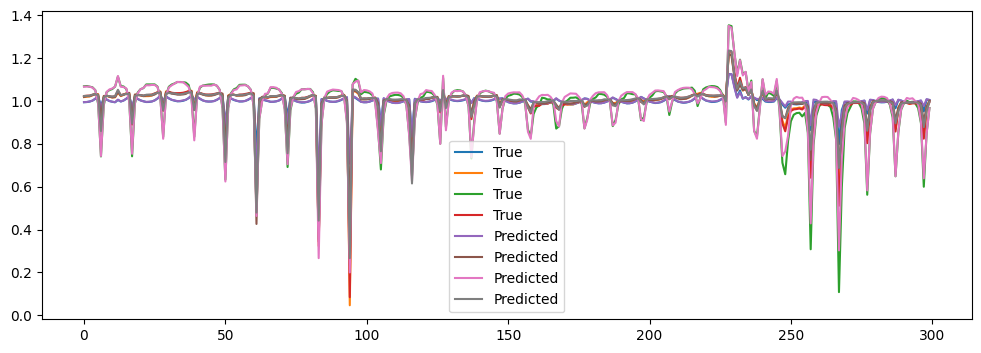

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(y_test1.values[:300], label='True')
plt.plot(pred2[:300], label='Predicted')
plt.legend()
plt.show()

In [ ]:
# Interpret PCA Loadings
loadings = pd.DataFrame(
    pca.components_.T,
    index=spectral_colsc,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

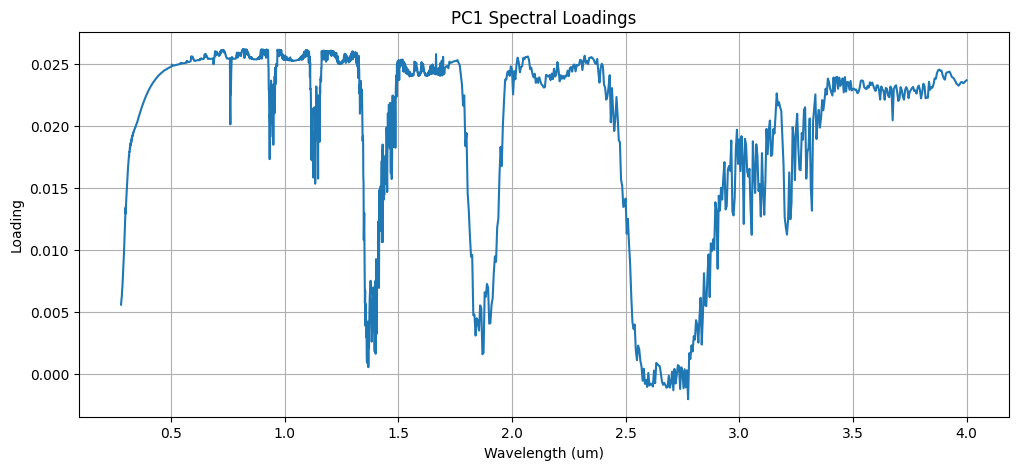

In [ ]:
# Plot PCA Loadings
wavelengths = [float(c.split()[0]) for c in spectral_colsc]

plt.figure(figsize=(12,5))

plt.plot(wavelengths, loadings['PC1'])

plt.xlabel('Wavelength (um)')
plt.ylabel('Loading')
plt.title('PC1 Spectral Loadings')

plt.grid(True)

plt.show()

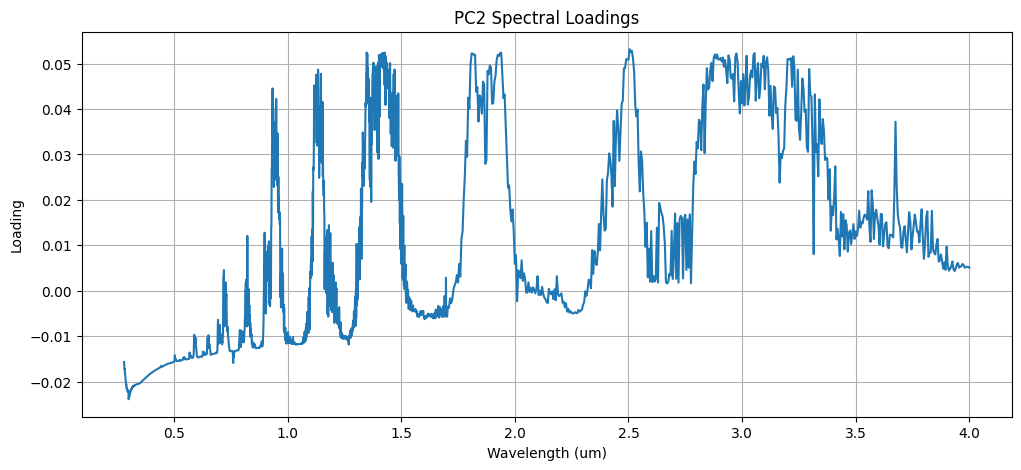

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(wavelengths, loadings['PC2'])

plt.xlabel('Wavelength (um)')
plt.ylabel('Loading')
plt.title('PC2 Spectral Loadings')

plt.grid(True)

plt.show()

In [ ]:
model2.feature_importances_

array([0.05180679, 0.05220495, 0.00668916, 0.00236138, 0.00369831,
       0.00318568, 0.02825343, 0.01064954, 0.25597858, 0.05444827,
       0.00041049, 0.03850722, 0.01052144, 0.03713305, 0.02876152,
       0.02307003, 0.03049619, 0.01288823, 0.04938446, 0.07263301,
       0.00955963, 0.02099947, 0.04494157, 0.09119436, 0.01735082,
       0.00365022, 0.00390297, 0.02049371, 0.01168699, 0.00149887,
       0.00163953], dtype=float32)

In [ ]:
# VERY IMPORTANT: you MUST map indices to feature names
import pandas as pd

feature_names = X_train2.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': model2.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

                feature  importance
8            Cloud Type    0.255979
23                 PC13    0.091194
19                  PC9    0.072633
9    Solar Zenith Angle    0.054448
1              hour_cos    0.052205
0              hour_sin    0.051807
18                  PC8    0.049384
22                 PC12    0.044942
11                  PC1    0.038507
13                  PC3    0.037133
16                  PC6    0.030496
14                  PC4    0.028762
6              Pressure    0.028253
15                  PC5    0.023070
21                 PC11    0.020999
27                 PC17    0.020494
24                 PC14    0.017351
17                  PC7    0.012888
28                 PC18    0.011687
7    Precipitable Water    0.010650
12                  PC2    0.010521
20                 PC10    0.009560
2               doy_sin    0.006689
26                 PC16    0.003903
4           Temperature    0.003698
25                 PC15    0.003650
5     Relative Humidity    0

<Axes: xlabel='feature'>

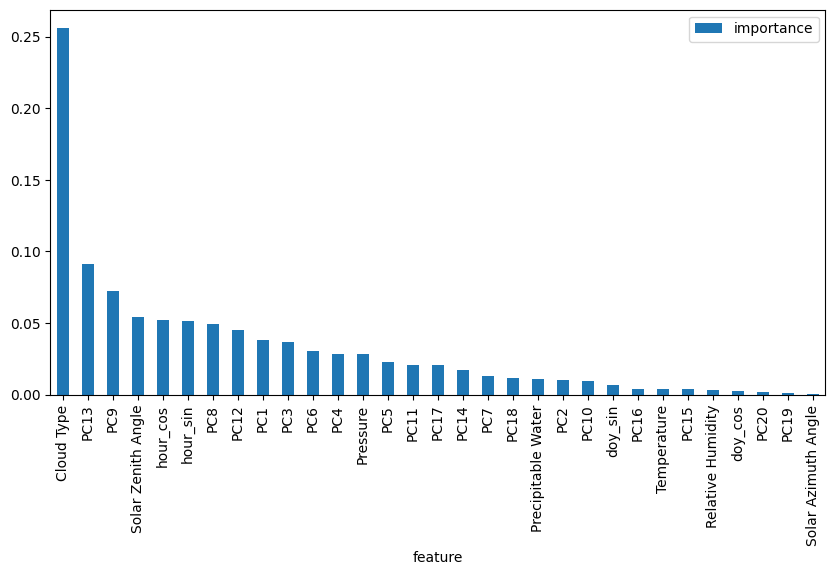

In [ ]:
# A. Plot feature importance
importance_df.plot.bar(x='feature', y='importance', figsize=(10,5))

In [ ]:
# Import SHAP
!pip install shap
import shap

# Calculate SHAP values


In [ ]:
# Create SHAP Explainer
explainer = shap.TreeExplainer(model2)

In [ ]:
# Compute SHAP Values
X_sample = X_test2.sample(500, random_state=42)

shap_values = explainer.shap_values(X_sample)

In [ ]:
print('PC11' in X_sample.columns)

True


In [ ]:
print(X_sample.columns)

Index(['hour_sin', 'hour_cos', 'doy_sin', 'doy_cos', 'Temperature',
       'Relative Humidity', 'Pressure', 'Precipitable Water', 'Cloud Type',
       'Solar Zenith Angle', 'Solar Azimuth Angle', 'PC1', 'PC2', 'PC3', 'PC4',
       'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13',
       'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20'],
      dtype='object')


In [ ]:
print(X_sample['Solar Zenith Angle'].describe())

count    500.00000
mean      61.71572
std       13.31447
min       35.22000
25%       51.44750
50%       60.58500
75%       72.32000
max       85.84000
Name: Solar Zenith Angle, dtype: float64


In [ ]:
print(shap_values.shape)
print(len(shap_values[0]))
print(len(shap_values[1]))
print(len(shap_values[2]))
print(len(shap_values[3]))
print(X_sample.shape)
print(len(X_sample.columns))

(500, 31, 4)
31
31
31
31
(500, 31)
31


In [ ]:
#X_sample = X_sample[X_train2.columns]

In [ ]:
# extract per material
shap_si   = shap_values[:, :, 0]
shap_gaas = shap_values[:, :, 1]
shap_ingap = shap_values[:, :, 2]
shap_cdte = shap_values[:, :, 3]

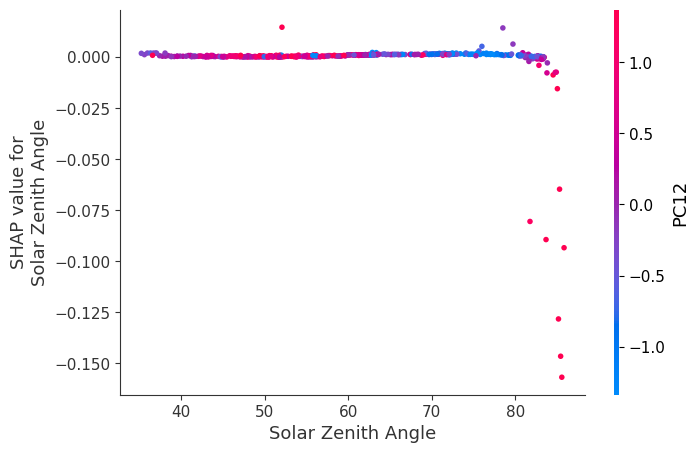

In [ ]:
shap.dependence_plot('Solar Zenith Angle',
                     shap_si,
                     X_sample,
                     )

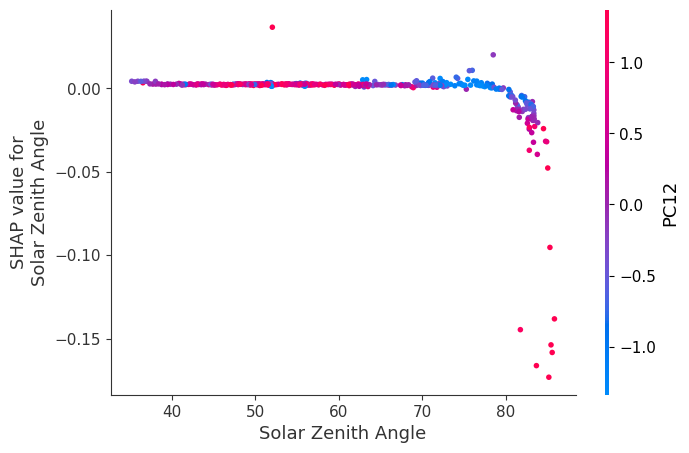

In [ ]:
shap.dependence_plot('Solar Zenith Angle', shap_gaas, X_sample)

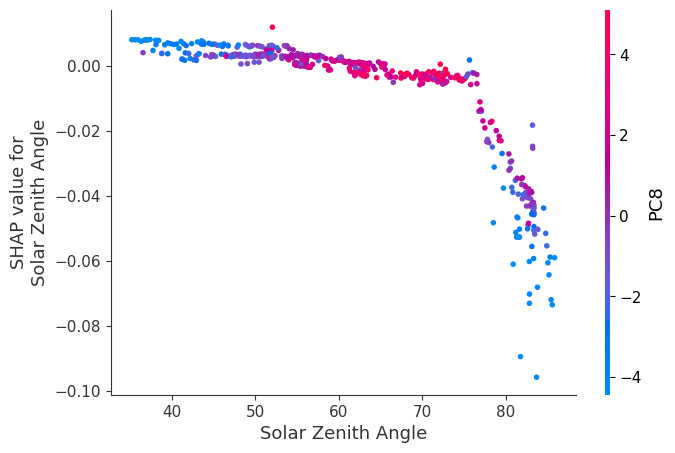

In [ ]:
shap.dependence_plot('Solar Zenith Angle', shap_ingap, X_sample)

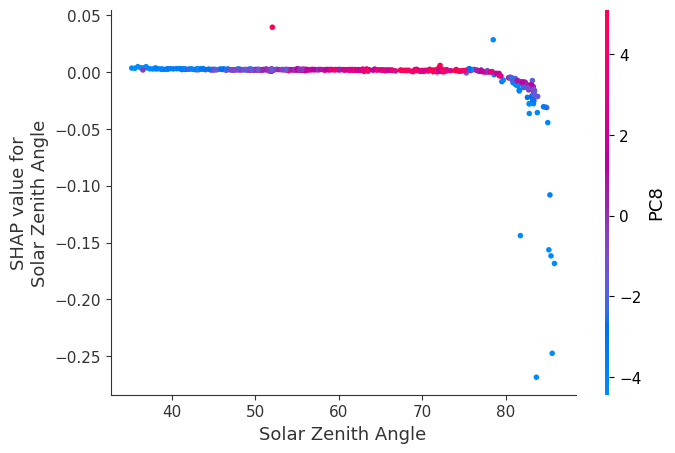

In [ ]:
shap.dependence_plot('Solar Zenith Angle', shap_cdte, X_sample)

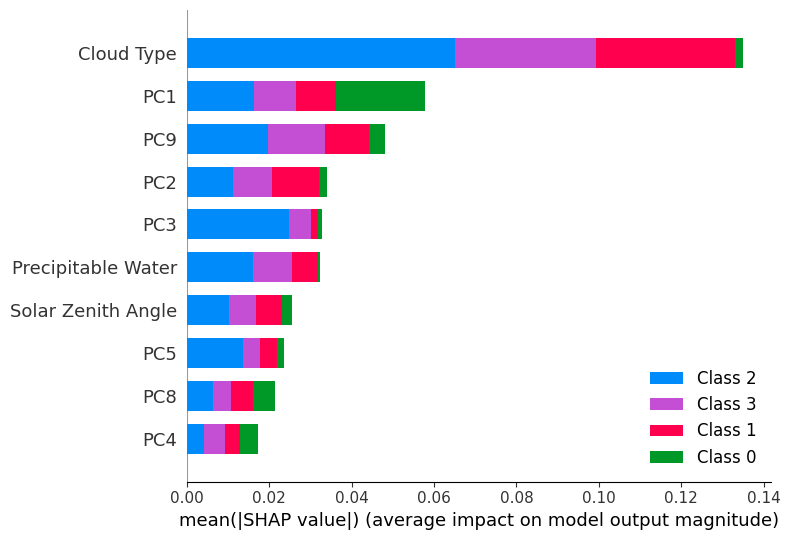

In [ ]:
# SHAP Summary Plot (VERY IMPORTANT)
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type='bar',
    max_display=10,
    show=True

)

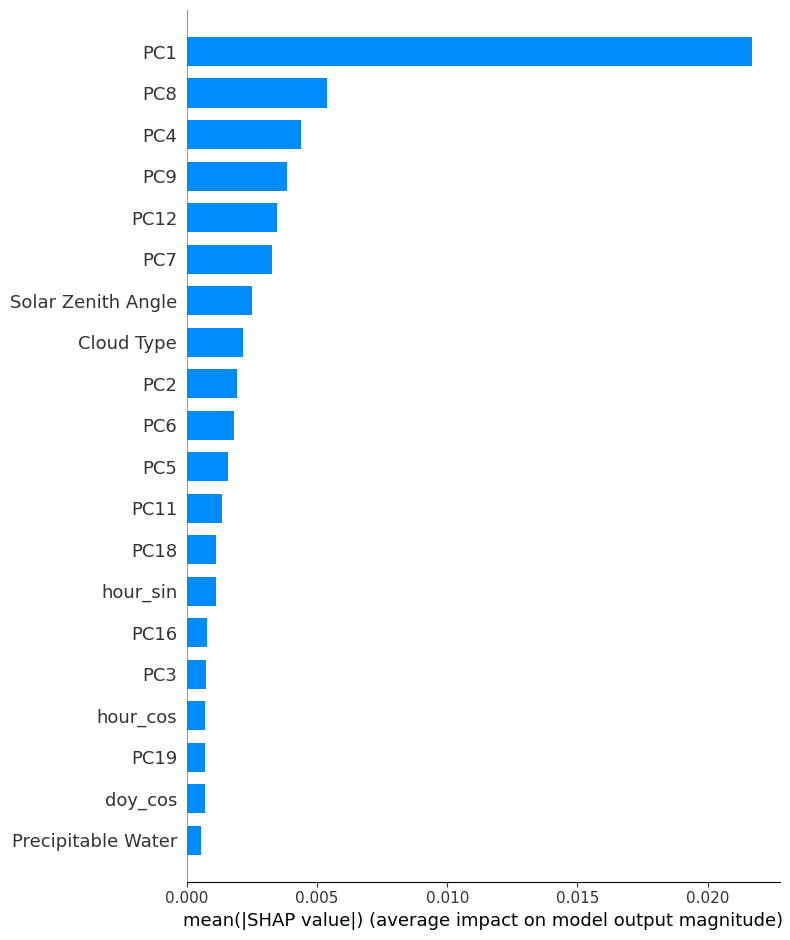

In [ ]:
shap.summary_plot(shap_si, X_sample, plot_type='bar')

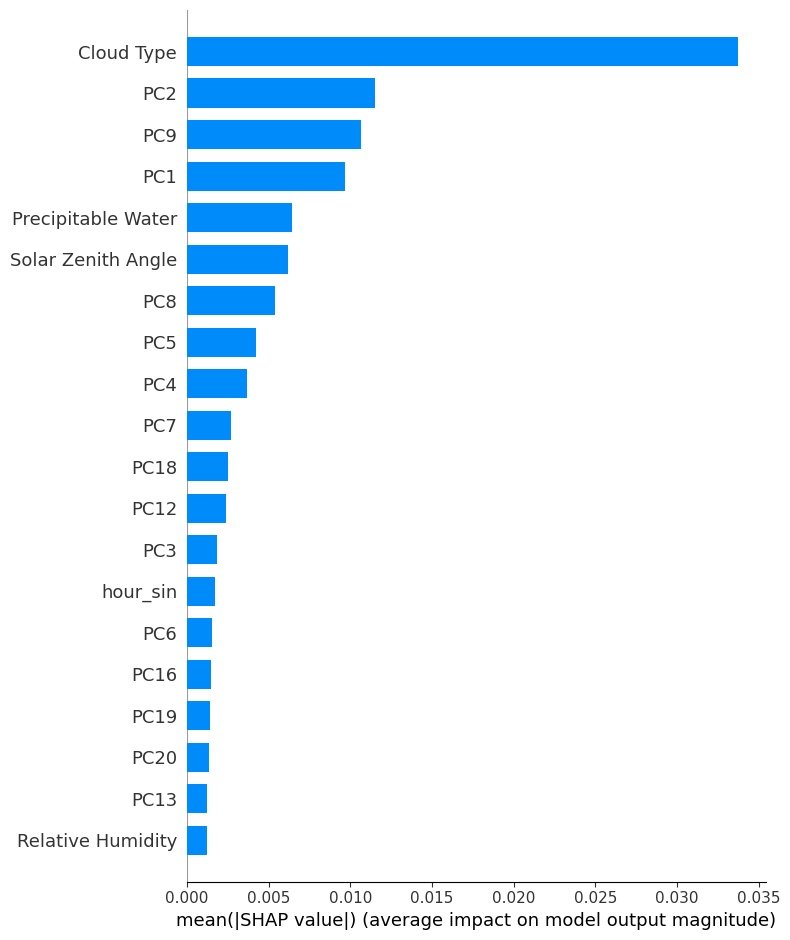

In [ ]:
shap.summary_plot(shap_gaas, X_sample, plot_type='bar')

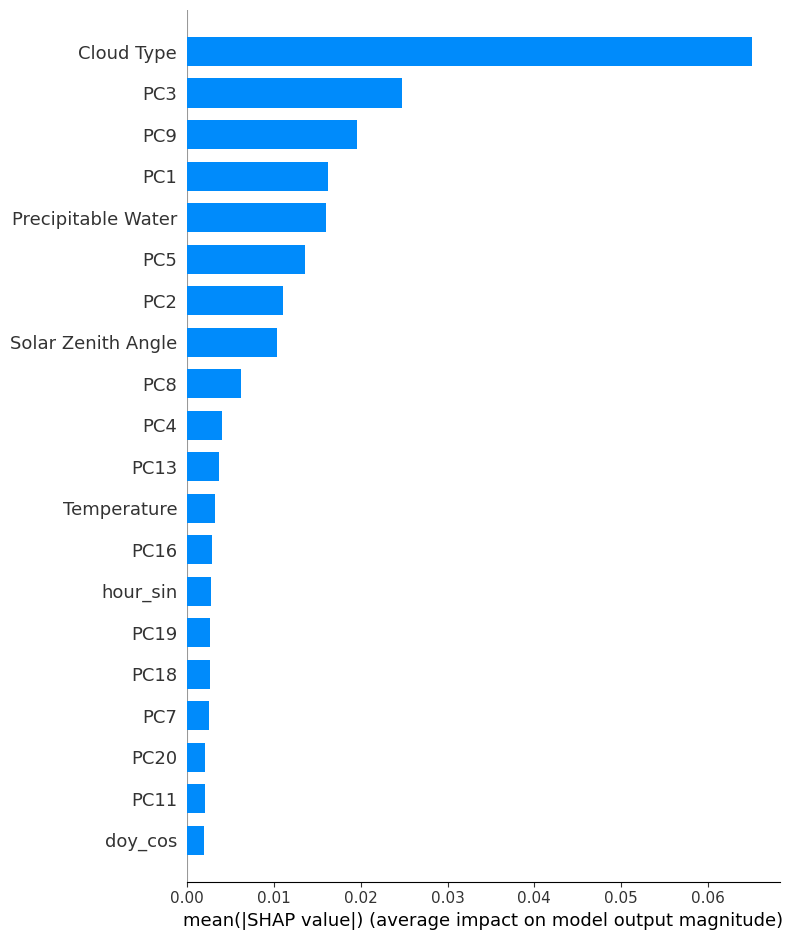

In [ ]:
shap.summary_plot(shap_ingap, X_sample, plot_type='bar')

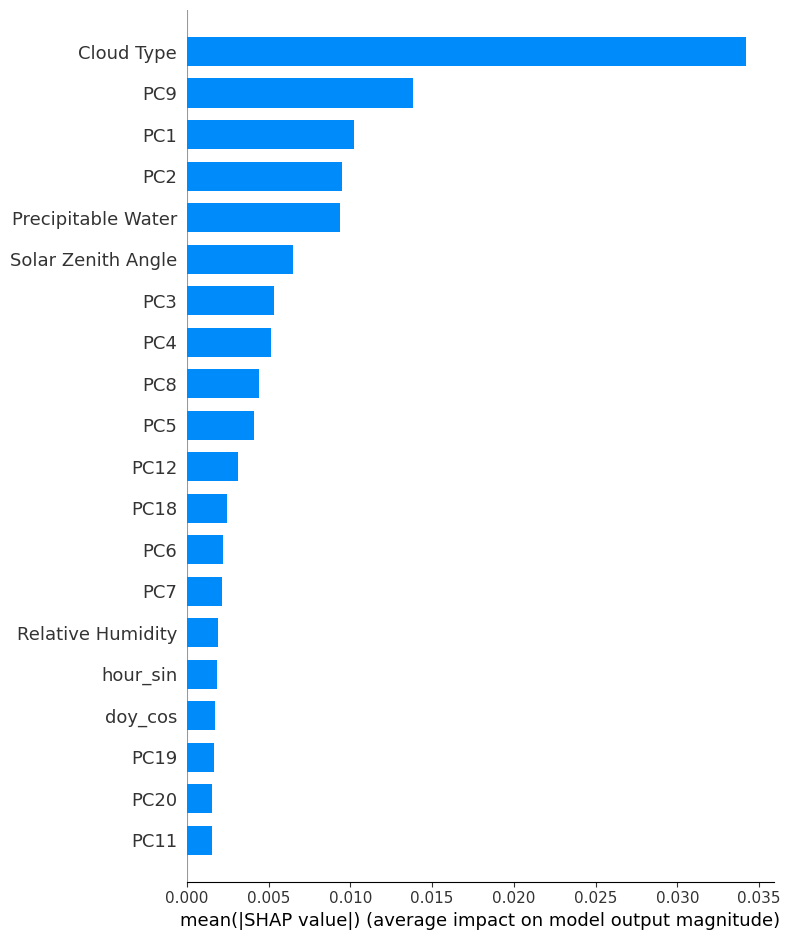

In [ ]:
shap.summary_plot(shap_cdte, X_sample, plot_type='bar')